### Show precise borders as contours (no rectangles)

This draws the true object outline using the mask.


image 1/1 /mnt/c/datasets/streetscapes/parkeerplaats.jpg: 384x640 9 cars, 3 trucks, 544.1ms
Speed: 1.3ms preprocess, 544.1ms inference, 5.9ms postprocess per image at shape (1, 3, 384, 640)


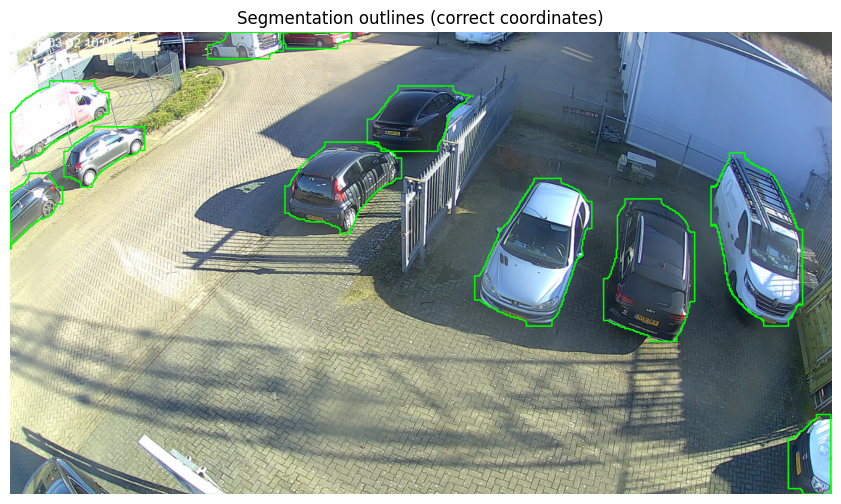

In [1]:

from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

seg_model = YOLO("/mnt/c/datasets/yolov8/models/yolov8x-seg.pt")  # <-- segmentation model (not yolov8l.pt)

image_path = Path("/mnt/c/datasets/streetscapes/parkeerplaats.jpg")
img = cv2.imread(str(image_path))

results = seg_model(str(image_path), conf=0.3)
r = results[0]

outline_img = img.copy()

if r.masks is None:
    print("No masks detected.")
else:
    # r.masks.xy is a list of polygons (each polygon is an Nx2 array of x,y points)
    for poly in r.masks.xy:
        pts = np.array(poly, dtype=np.int32)          # shape (N, 2)
        pts = pts.reshape((-1, 1, 2))                 # OpenCV expects (N, 1, 2)
        cv2.polylines(outline_img, [pts], True, (0, 255, 0), 2)

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(outline_img, cv2.COLOR_BGR2RGB))
plt.title("Segmentation outlines (correct coordinates)")
plt.axis("off")
plt.show()

### Mask overlay (semi-transparent fill) + outline

This is the “classic” segmentation look: filled mask + contour edge.


image 1/1 /mnt/c/datasets/streetscapes/parkeerplaats.jpg: 384x640 9 cars, 3 trucks, 551.8ms
Speed: 1.1ms preprocess, 551.8ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)


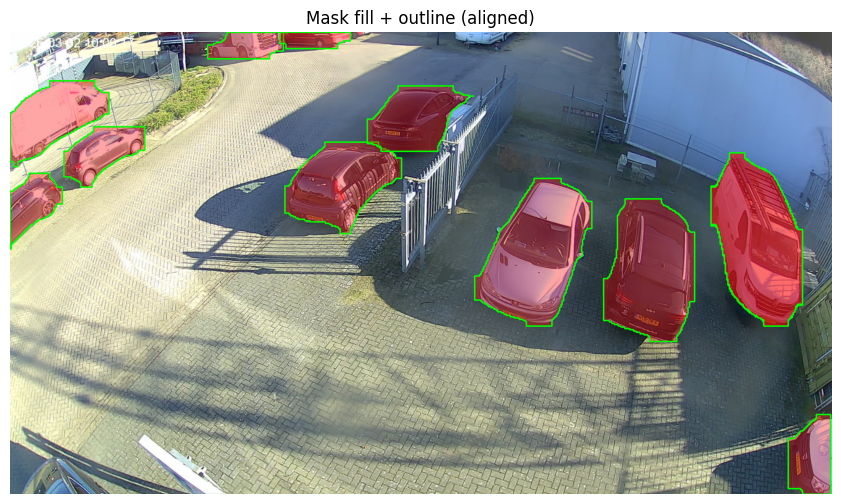

In [2]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

seg_model = YOLO("/mnt/c/datasets/yolov8/models/yolov8x-seg.pt")  # <-- segmentation model (not yolov8l.pt)

image_path = Path("/mnt/c/datasets/streetscapes/parkeerplaats.jpg")
img = cv2.imread(str(image_path))

results = seg_model(str(image_path), conf=0.3)
r = results[0]

overlay_img = img.copy()

if r.masks is None:
    print("No masks detected.")
else:
    alpha = 0.35  # transparency
    fill_color_bgr = (0, 0, 255)  # red

    for poly in r.masks.xy:
        # Polygon points in original image coords
        pts = np.array(poly, dtype=np.int32).reshape((-1, 1, 2))

        # 1) Fill on a temp overlay
        temp = overlay_img.copy()
        cv2.fillPoly(temp, [pts], fill_color_bgr)

        # 2) Blend filled region with current image
        overlay_img = cv2.addWeighted(overlay_img, 1 - alpha, temp, alpha, 0)

        # 3) Draw outline on top
        cv2.polylines(overlay_img, [pts], True, (0, 255, 0), 2)

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB))
plt.title("Mask fill + outline (aligned)")
plt.axis("off")
plt.show()

### Precise masking of objects (blur/black/color) using the mask shape

This does what you were doing with rectangles, but only inside the object shape.


image 1/1 /mnt/c/datasets/streetscapes/parkeerplaats.jpg: 384x640 9 cars, 3 trucks, 580.7ms
Speed: 2.0ms preprocess, 580.7ms inference, 2.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /mnt/c/datasets/streetscapes/parkeerplaats.jpg: 384x640 9 cars, 3 trucks, 478.3ms
Speed: 1.2ms preprocess, 478.3ms inference, 3.8ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /mnt/c/datasets/streetscapes/parkeerplaats.jpg: 384x640 9 cars, 3 trucks, 495.2ms
Speed: 1.2ms preprocess, 495.2ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)


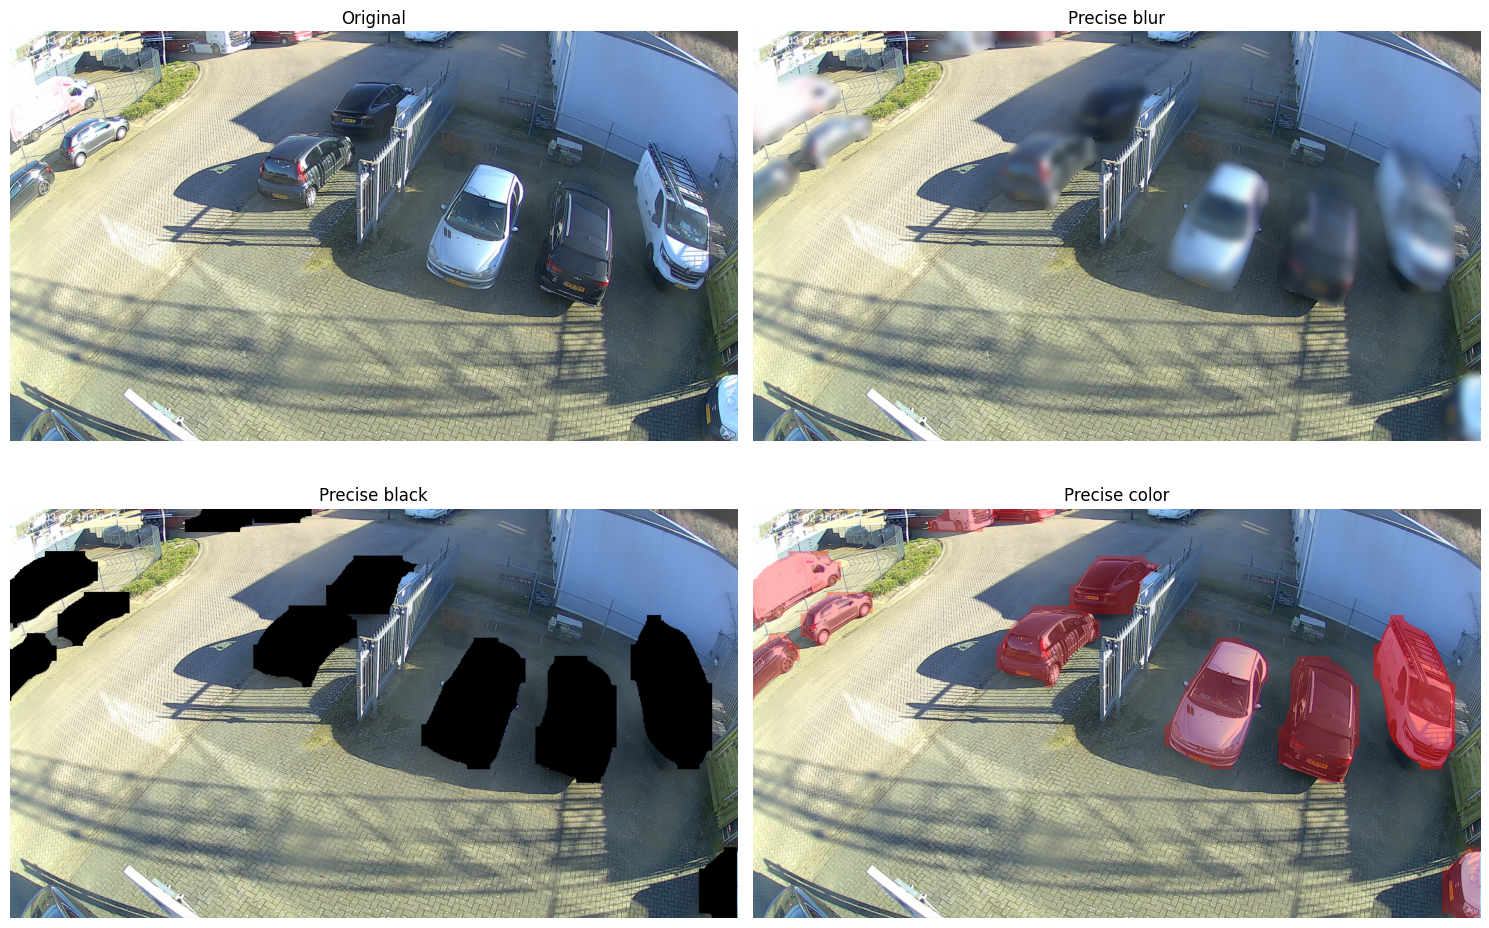

In [3]:
def apply_mask_mode(img_bgr, pts, mode="blur"):
    """
    img_bgr: BGR image
    pts: polygon points shape (N,1,2) in original coords
    """
    out = img_bgr.copy()

    # Build a binary mask for this polygon
    mask = np.zeros(img_bgr.shape[:2], dtype=np.uint8)
    cv2.fillPoly(mask, [pts], 255)
    mask_bool = mask.astype(bool)

    match mode:
        case "blur":
            blurred = cv2.GaussianBlur(out, (51, 51), 0)
            out[mask_bool] = blurred[mask_bool]

        case "black":
            out[mask_bool] = 0

        case "color":
            # Semi-transparent red only inside mask
            red = np.zeros_like(out, dtype=np.uint8)
            red[:] = (0, 0, 255)
            blended = cv2.addWeighted(out, 0.7, red, 0.3, 0)
            out[mask_bool] = blended[mask_bool]

        case _:
            raise ValueError(f"Unknown mode: {mode}")

    return out


def mask_objects_precise(image_path: str, conf: float = 0.3, mode: str = "blur"):
    img = cv2.imread(image_path)
    results = seg_model(image_path, conf=conf)
    r = results[0]

    if r.masks is None:
        return img

    out = img.copy()
    for poly in r.masks.xy:
        pts = np.array(poly, dtype=np.int32).reshape((-1, 1, 2))
        out = apply_mask_mode(out, pts, mode=mode)

    return out


masked_blur = mask_objects_precise(("/mnt/c/datasets/streetscapes/parkeerplaats.jpg"), conf=0.3, mode="blur")
masked_black = mask_objects_precise(("/mnt/c/datasets/streetscapes/parkeerplaats.jpg"), conf=0.3, mode="black")
masked_color = mask_objects_precise(("/mnt/c/datasets/streetscapes/parkeerplaats.jpg"), conf=0.3, mode="color")

plt.figure(figsize=(15, 10))

for i, (title, im) in enumerate([
    ("Original", cv2.imread("/mnt/c/datasets/streetscapes/parkeerplaats.jpg")),
    ("Precise blur", masked_blur),
    ("Precise black", masked_black),
    ("Precise color", masked_color),
]):
    plt.subplot(2, 2, i + 1)
    plt.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()